# Model Training (Final Run)

Train the character-level GPT with **best hyperparameters** from [4. Hyperparameter Tuning.ipynb](4.%20%20%20Hyperparameter%20Tuning.ipynb).

## Features

- **Cosine LR**: linear warmup (0–200) to peak LR, then cosine decay to 10% of peak by step 5000
- **Best checkpointing**: save `gpt_best.pt` immediately whenever validation loss improves
- **Early stopping**: halt if val loss does not improve for 500 eval intervals (50k steps max wait — actually 500 steps without improvement)
- **Reproducibility**: lock Python/NumPy/PyTorch seeds immediately before model init

## Prerequisites

1. Run `2. Preprocessing.ipynb` → `data/artifacts/`
2. Run sweep in `4. Hyperparameter Tuning.ipynb` (or use offline fallback config)
3. `pip install wandb` and `wandb login` for experiment tracking


In [1]:
from pathlib import Path
import random
import time
import math
import json
import copy

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import wandb
except ImportError as e:
    raise ImportError("Install wandb: pip install wandb") from e

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-darkgrid")

cwd = Path.cwd()
if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(f"Could not locate a 'data' directory from cwd: {cwd}")

DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = DATA_DIR / "artifacts"
CHECKPOINT_DIR = ARTIFACTS_DIR / "model"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH = CHECKPOINT_DIR / "gpt_best.pt"

BASE_CONFIG = {
    "seed": 42,
    "block_size": 128,
    "batch_size": 32,
    "max_steps": 5000,
    "eval_interval": 100,
    "eval_batches": 50,
    "betas": (0.9, 0.95),
    "d_ff": 4,
    "grad_accum_steps": 4,
    "use_amp": True,
    "early_stop_patience": 500,
    "wandb_project": "genre-story-generator",
    "wandb_entity": None,
    "wandb_group": "final-run",
    "wandb_job_type": "final-training",
    "run_name": "sweep-best-final-v1",
}

SWEEP_ID = "kbmij8of"
SWEEP_METRIC = "val/loss"
SWEEP_PARAMS = [
    "learning_rate",
    "n_layers",
    "d_model",
    "n_heads",
    "dropout",
    "weight_decay",
    "warmup_steps",
]

FALLBACK_BEST = {
    "run_id": "zhocttbr",
    "run_name": "earthy-sweep-6",
    "val/loss": 1.4392,
    "learning_rate": 0.00125916,
    "n_layers": 5,
    "d_model": 512,
    "n_heads": 8,
    "dropout": 0.15540136469775573,
    "weight_decay": 0.2,
    "warmup_steps": 200,
}

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def _sweep_api_path(sweep_id: str) -> str:
    project = BASE_CONFIG["wandb_project"]
    entity = BASE_CONFIG.get("wandb_entity")
    if entity is None:
        entity = wandb.Api().default_entity
    return f"{entity}/{project}/{sweep_id}"


def fetch_sweep_runs(sweep_id: str) -> pd.DataFrame:
    api = wandb.Api()
    sweep = api.sweep(_sweep_api_path(sweep_id))
    rows = []
    for run in sweep.runs:
        hist = run.history(keys=[SWEEP_METRIC, "val/perplexity"])
        if len(hist) and SWEEP_METRIC in hist.columns and hist[SWEEP_METRIC].notna().any():
            best_idx = hist[SWEEP_METRIC].idxmin()
            best_val = float(hist.loc[best_idx, SWEEP_METRIC])
            best_ppl = (
                float(hist.loc[best_idx, "val/perplexity"])
                if "val/perplexity" in hist.columns and pd.notna(hist.loc[best_idx, "val/perplexity"])
                else math.exp(best_val)
            )
        elif run.summary.get(SWEEP_METRIC) is not None:
            best_val = float(run.summary[SWEEP_METRIC])
            best_ppl = float(run.summary.get("val/perplexity") or math.exp(best_val))
        else:
            continue
        row = {
            "run_id": run.id,
            "run_name": run.name,
            "state": run.state,
            SWEEP_METRIC: best_val,
            "val/perplexity": best_ppl,
            "model/parameters": run.summary.get("model/parameters"),
        }
        for param in SWEEP_PARAMS:
            row[param] = run.config.get(param)
        rows.append(row)
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    sort_cols = [SWEEP_METRIC]
    ascending = [True]
    if df["model/parameters"].notna().any():
        sort_cols.append("model/parameters")
        ascending.append(True)
    return df.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)


def resolve_final_config() -> tuple[dict, dict]:
    sweep_meta = {"sweep_id": SWEEP_ID}
    try:
        runs_df = fetch_sweep_runs(SWEEP_ID)
    except Exception as exc:
        print(f"W&B fetch failed ({exc}); using FALLBACK_BEST.")
        runs_df = pd.DataFrame()

    if runs_df.empty:
        best_row = FALLBACK_BEST.copy()
        sweep_meta["source"] = "fallback"
    else:
        best_row = runs_df.iloc[0].to_dict()
        sweep_meta["source"] = "wandb"
        sweep_meta["run_id"] = best_row.get("run_id")
        sweep_meta["run_name"] = best_row.get("run_name")

    config = {**BASE_CONFIG}
    for param in SWEEP_PARAMS:
        if param in best_row and best_row[param] is not None:
            val = best_row[param]
            if param == "warmup_steps":
                val = int(val)
            elif param in ("n_layers", "n_heads", "d_model"):
                val = int(val)
            config[param] = val

    peak_lr = float(config["learning_rate"])
    config["min_lr"] = peak_lr * 0.1
    config["sweep_best_val_loss"] = float(best_row.get(SWEEP_METRIC, best_row.get("val/loss", float("inf"))))

    sweep_meta["sweep_best_val_loss"] = config["sweep_best_val_loss"]
    sweep_meta["hyperparameters"] = {p: config[p] for p in SWEEP_PARAMS}

    out_path = ARTIFACTS_DIR / "sweep_best_config.json"
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(sweep_meta, f, indent=2, default=str)
    print(f"Wrote {out_path}")

    return config, sweep_meta


FINAL_CONFIG, SWEEP_META = resolve_final_config()
print("\n--- FINAL_CONFIG (sweep-best + final-run overrides) ---")
for k in ["learning_rate", "min_lr", "warmup_steps", "max_steps", "n_layers", "d_model", "n_heads", "dropout", "weight_decay", "eval_interval", "early_stop_patience"]:
    print(f"  {k}: {FINAL_CONFIG.get(k)}")
print(f"  sweep_best_val_loss: {FINAL_CONFIG['sweep_best_val_loss']:.4f}")


Using device: cuda


wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/gwr4170/.netrc.


Wrote /projects/e32706/gwr4170/Text Generation/genre-story-generator/data/artifacts/sweep_best_config.json

--- FINAL_CONFIG (sweep-best + final-run overrides) ---
  learning_rate: 0.0012591646667164046
  min_lr: 0.00012591646667164046
  warmup_steps: 200
  max_steps: 5000
  n_layers: 5
  d_model: 512
  n_heads: 8
  dropout: 0.15540136469775573
  weight_decay: 0.2
  eval_interval: 100
  early_stop_patience: 500
  sweep_best_val_loss: 1.4392


## Load Artifacts

Preprocessed token tensors and character vocabulary from notebook 2.


In [2]:
train_ids_path = ARTIFACTS_DIR / "train_ids.pt"
val_ids_path = ARTIFACTS_DIR / "val_ids.pt"
vocab_path = ARTIFACTS_DIR / "char_vocab.json"

for p in (train_ids_path, val_ids_path, vocab_path):
    assert p.exists(), f"Missing {p}. Run preprocessing notebook first."

train_ids = torch.load(train_ids_path, weights_only=True)
val_ids = torch.load(val_ids_path, weights_only=True)

with open(vocab_path, "r", encoding="utf-8") as f:
    vocab_payload = json.load(f)

vocab_size = vocab_payload["vocab_size"]
stoi = vocab_payload["stoi"]
itos = {int(k): v for k, v in vocab_payload["itos"].items()}


def encode(text: str):
    return [stoi[ch] for ch in text]


def decode(indices):
    return "".join(itos[int(i)] for i in indices)


def get_batch(split: str, batch_size: int, block_size: int, device: str = device):
    data = train_ids if split == "train" else val_ids
    if len(data) <= block_size:
        raise ValueError(f"{split} split too short for block_size={block_size}")
    ix = torch.randint(0, len(data) - block_size - 1, (batch_size,))
    x = torch.stack([data[i : i + block_size] for i in ix])
    y = torch.stack([data[i + 1 : i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)


print(f"train_ids: {train_ids.shape} | val_ids: {val_ids.shape} | vocab: {vocab_size}")


train_ids: torch.Size([1003836]) | val_ids: torch.Size([55762]) | vocab: 65


## Model Architecture

Decoder-only GPT (same family as notebook 4) with `generate()` for qualitative evaluation.


In [3]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.qkv_proj = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        self.register_buffer("mask", None, persistent=False)

    def _causal_mask(self, size: int, device: torch.device):
        if self.mask is None or self.mask.size(0) < size:
            self.mask = torch.tril(torch.ones(size, size, device=device)).view(1, 1, size, size)
        return self.mask[:, :, :size, :size]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.size()
        qkv = self.qkv_proj(x)
        q, k, v = qkv.chunk(3, dim=-1)

        def reshape_heads(t):
            return t.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        q, k, v = reshape_heads(q), reshape_heads(k), reshape_heads(v)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        mask = self._causal_mask(T, x.device)
        att = att.masked_fill(mask[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_dropout(self.out_proj(y))


class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff_mult: int, dropout: float):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff_mult * d_model),
            nn.GELU(),
            nn.Linear(d_ff_mult * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


class GPTLanguageModel(nn.Module):
    def __init__(self, vocab_size: int, config: dict):
        super().__init__()
        d_model = config["d_model"]
        n_heads = config["n_heads"]
        n_layers = config["n_layers"]
        dropout = config["dropout"]
        block_size = config["block_size"]
        d_ff_mult = config.get("d_ff", 4)
        self.block_size = block_size
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(block_size, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, n_heads, d_ff_mult, dropout) for _ in range(n_layers)]
        )
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx: torch.Tensor, targets: torch.Tensor | None = None):
        B, T = idx.size()
        if T > self.block_size:
            raise ValueError(f"Sequence length {T} exceeds block_size {self.block_size}")
        pos = torch.arange(0, T, device=idx.device, dtype=torch.long).unsqueeze(0)
        x = self.drop(self.token_embedding(idx) + self.pos_embedding(pos))
        for block in self.blocks:
            x = block(x)
        logits = self.head(self.ln_f(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(B * T, -1), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(
        self,
        idx: torch.Tensor,
        max_new_tokens: int,
        temperature: float = 1.0,
        top_k: int = 0,
        top_p: float = 1.0,
    ):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size :]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / max(temperature, 1e-8)
            if top_k > 0:
                k = min(top_k, logits.size(-1))
                v, _ = torch.topk(logits, k, dim=-1)
                logits = logits.masked_fill(logits < v[:, [-1]], float("-inf"))
            if top_p < 1.0:
                sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
                cum_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
                remove = cum_probs - F.softmax(sorted_logits, dim=-1) >= top_p
                sorted_logits[remove] = float("-inf")
                logits = sorted_logits.scatter(1, sorted_idx, sorted_logits)
            probs = F.softmax(logits, dim=-1)
            idx = torch.cat([idx, torch.multinomial(probs, num_samples=1)], dim=1)
        return idx


## Learning Rate Schedule

Linear warmup to peak LR, then cosine decay to `min_lr = 0.1 * peak_lr`.


In [4]:
class CosineWarmupScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_steps: int, max_steps: int, min_lr: float = 0.0, last_epoch: int = -1):
        self.warmup_steps = warmup_steps
        self.max_steps = max_steps
        self.min_lr = min_lr
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        step = self.last_epoch + 1
        if step < self.warmup_steps:
            scale = step / max(1, self.warmup_steps)
        else:
            progress = (step - self.warmup_steps) / max(1, self.max_steps - self.warmup_steps)
            progress = min(max(progress, 0.0), 1.0)
            scale = 0.5 * (1.0 + math.cos(math.pi * progress))
        return [self.min_lr + (base_lr - self.min_lr) * scale for base_lr in self.base_lrs]


def preview_lr_schedule(config: dict, steps: list[int]):
    opt = torch.optim.SGD([torch.zeros(1, requires_grad=True)], lr=config["learning_rate"])
    sched = CosineWarmupScheduler(
        opt,
        warmup_steps=config["warmup_steps"],
        max_steps=config["max_steps"],
        min_lr=config["min_lr"],
    )
    print("LR schedule preview:")
    for target in steps:
        while sched.last_epoch + 1 < target:
            sched.step()
        lr = sched.get_lr()[0]
        print(f"  step {target:5d}: lr = {lr:.6g}")


## Train

Lock seeds → build model → train with AMP, grad accumulation, frequent eval, best checkpointing, and early stopping.


In [5]:
set_seed(FINAL_CONFIG["seed"])
preview_lr_schedule(FINAL_CONFIG, [1, 200, 201, 2500, FINAL_CONFIG["max_steps"]])


def create_model_and_optimizer(config: dict):
    model = GPTLanguageModel(vocab_size=vocab_size, config=config).to(device)
    decay_params, no_decay_params = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if p.dim() >= 2 and "bias" not in name and "norm" not in name.lower():
            decay_params.append(p)
        else:
            no_decay_params.append(p)
    optimizer = torch.optim.AdamW(
        [
            {"params": decay_params, "weight_decay": config["weight_decay"]},
            {"params": no_decay_params, "weight_decay": 0.0},
        ],
        lr=config["learning_rate"],
        betas=tuple(config.get("betas", (0.9, 0.95))),
    )
    scheduler = CosineWarmupScheduler(
        optimizer,
        warmup_steps=config["warmup_steps"],
        max_steps=config["max_steps"],
        min_lr=config["min_lr"],
    )
    return model, optimizer, scheduler


@torch.no_grad()
def estimate_loss(model: nn.Module, config: dict, num_batches: int | None = None):
    model.eval()
    num_batches = num_batches or config["eval_batches"]
    out = {}
    for split in ("train", "val"):
        losses = []
        for _ in range(num_batches):
            x, y = get_batch(split, config["batch_size"], config["block_size"], device)
            with torch.amp.autocast(device_type=device, enabled=config["use_amp"]):
                _, loss = model(x, y)
            losses.append(loss.item())
        avg = float(np.mean(losses))
        out[split] = {"loss": avg, "ppl": math.exp(avg)}
    model.train()
    return out


def save_best_checkpoint(model: nn.Module, config: dict, path: Path = CKPT_PATH):
    payload = {
        "model": {k: v.cpu().clone() for k, v in model.state_dict().items()},
        "config": copy.deepcopy(config),
    }
    torch.save(payload, path)


model, optimizer, scheduler = create_model_and_optimizer(FINAL_CONFIG)
scaler = torch.amp.GradScaler(enabled=FINAL_CONFIG["use_amp"])
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")

run = wandb.init(
    project=FINAL_CONFIG["wandb_project"],
    entity=FINAL_CONFIG.get("wandb_entity"),
    group=FINAL_CONFIG["wandb_group"],
    job_type=FINAL_CONFIG["wandb_job_type"],
    name=FINAL_CONFIG.get("run_name"),
    config=FINAL_CONFIG,
)
wandb.log({"model/parameters": n_params})

max_steps = FINAL_CONFIG["max_steps"]
eval_interval = FINAL_CONFIG["eval_interval"]
grad_accum = FINAL_CONFIG["grad_accum_steps"]
patience = FINAL_CONFIG["early_stop_patience"]

sweep_best_val_loss = FINAL_CONFIG["sweep_best_val_loss"]
best_val_loss = float("inf")
steps_since_improvement = 0
early_stopped = False
stopped_step = max_steps

history = {
    "step": [],
    "train_loss": [],
    "val_loss": [],
    "train_ppl": [],
    "val_ppl": [],
    "lr": [],
}

model.train()
t0 = time.time()
last_train_loss = None

for step in range(max_steps):
    optimizer.zero_grad(set_to_none=True)
    micro_loss = 0.0
    for _ in range(grad_accum):
        x, y = get_batch("train", FINAL_CONFIG["batch_size"], FINAL_CONFIG["block_size"], device)
        with torch.amp.autocast(device_type=device, enabled=FINAL_CONFIG["use_amp"]):
            _, loss = model(x, y)
            loss = loss / grad_accum
        scaler.scale(loss).backward()
        micro_loss += loss.item()
    last_train_loss = micro_loss * grad_accum

    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()
    scheduler.step()

    if (step + 1) % eval_interval == 0 or step == max_steps - 1:
        metrics = estimate_loss(model, FINAL_CONFIG)
        tl, vl = metrics["train"]["loss"], metrics["val"]["loss"]
        lr = optimizer.param_groups[0]["lr"]
        history["step"].append(step + 1)
        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_ppl"].append(metrics["train"]["ppl"])
        history["val_ppl"].append(metrics["val"]["ppl"])
        history["lr"].append(lr)

        log_payload = {
            "train/loss": tl,
            "val/loss": vl,
            "val/perplexity": metrics["val"]["ppl"],
            "train/perplexity": metrics["train"]["ppl"],
            "optim/lr": lr,
            "train/micro_loss": last_train_loss,
            "train/step": step + 1,
        }

        if vl < best_val_loss:
            best_val_loss = vl
            steps_since_improvement = 0
            save_best_checkpoint(model, FINAL_CONFIG)
            log_payload["checkpoint/saved"] = 1
            log_payload["checkpoint/best_val_loss"] = best_val_loss
            print(
                f"  Step {step+1:5d} | NEW BEST val {vl:.4f} (ppl {metrics['val']['ppl']:.1f}) | "
                f"train {tl:.4f} | saved {CKPT_PATH.name}"
            )
        else:
            steps_since_improvement += eval_interval
            log_payload["checkpoint/saved"] = 0
            print(
                f"  Step {step+1:5d} | val {vl:.4f} (ppl {metrics['val']['ppl']:.1f}) | "
                f"train {tl:.4f} | no improve {steps_since_improvement}/{patience}"
            )

        wandb.log(log_payload, step=step + 1)

        if steps_since_improvement >= patience:
            early_stopped = True
            stopped_step = step + 1
            print(f"Early stopping at step {stopped_step}: no val improvement for {patience} steps.")
            break

elapsed = time.time() - t0
print(f"Training finished in {elapsed:.1f}s | stopped_step={stopped_step} | early_stopped={early_stopped}")

if CKPT_PATH.exists():
    ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model"])
    model.to(device)
    print(f"Restored best checkpoint (val/loss={best_val_loss:.4f})")
else:
    print("Warning: no checkpoint saved (val loss never improved). Using last weights.")


LR schedule preview:
  step     1: lr = 0.000131583
  step   200: lr = 0.00125916
  step   201: lr = 0.00125916
  step  2500: lr = 0.0007296
  step  5000: lr = 0.000125916


/home/gwr4170/.conda/envs/pix2pix/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
wandb: Currently logged in as: utki007 (utki007-northwestern-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Model parameters: 15,895,040


  Step   100 | NEW BEST val 2.3450 (ppl 10.4) | train 2.3272 | saved gpt_best.pt
  Step   200 | NEW BEST val 1.9393 (ppl 7.0) | train 1.8137 | saved gpt_best.pt
  Step   300 | NEW BEST val 1.7215 (ppl 5.6) | train 1.5785 | saved gpt_best.pt
  Step   400 | NEW BEST val 1.6044 (ppl 5.0) | train 1.4591 | saved gpt_best.pt
  Step   500 | NEW BEST val 1.5177 (ppl 4.6) | train 1.3790 | saved gpt_best.pt
  Step   600 | NEW BEST val 1.4882 (ppl 4.4) | train 1.3313 | saved gpt_best.pt
  Step   700 | NEW BEST val 1.4652 (ppl 4.3) | train 1.2816 | saved gpt_best.pt
  Step   800 | NEW BEST val 1.4251 (ppl 4.2) | train 1.2415 | saved gpt_best.pt
  Step   900 | NEW BEST val 1.4165 (ppl 4.1) | train 1.2088 | saved gpt_best.pt
  Step  1000 | NEW BEST val 1.4139 (ppl 4.1) | train 1.1851 | saved gpt_best.pt
  Step  1100 | NEW BEST val 1.4050 (ppl 4.1) | train 1.1579 | saved gpt_best.pt
  Step  1200 | NEW BEST val 1.4043 (ppl 4.1) | train 1.1428 | saved gpt_best.pt
  Step  1300 | NEW BEST val 1.4034 (ppl

### Training Curves


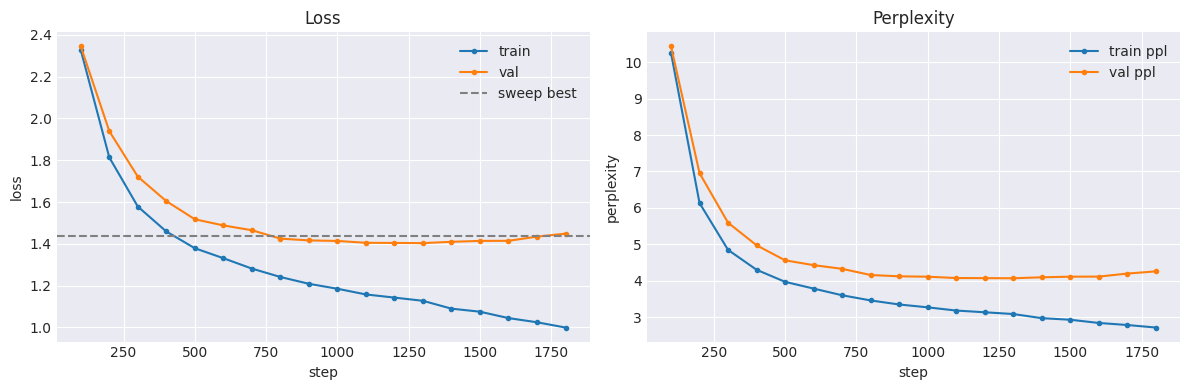

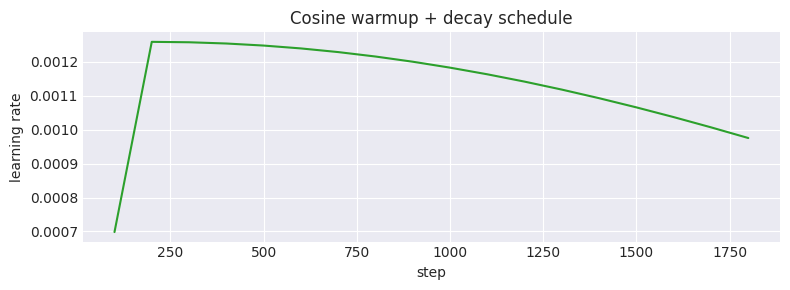

In [6]:
if not history["step"]:
    print("No eval history to plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["step"], history["train_loss"], label="train", marker="o", markersize=3)
    axes[0].plot(history["step"], history["val_loss"], label="val", marker="o", markersize=3)
    axes[0].axhline(sweep_best_val_loss, color="gray", ls="--", label="sweep best")
    axes[0].set_xlabel("step")
    axes[0].set_ylabel("loss")
    axes[0].set_title("Loss")
    axes[0].legend()

    ax2 = axes[1]
    ax2.plot(history["step"], history["train_ppl"], label="train ppl", marker="o", markersize=3)
    ax2.plot(history["step"], history["val_ppl"], label="val ppl", marker="o", markersize=3)
    ax2.set_xlabel("step")
    ax2.set_ylabel("perplexity")
    ax2.set_title("Perplexity")
    ax2.legend()

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 3))
    plt.plot(history["step"], history["lr"], color="C2")
    plt.xlabel("step")
    plt.ylabel("learning rate")
    plt.title("Cosine warmup + decay schedule")
    plt.tight_layout()
    plt.show()


## Qualitative Generation

Samples from the best checkpoint (validation-optimal weights).


In [7]:
model.eval()
prompts = {
    "greedy": {"temperature": 1.0, "top_k": 0, "top_p": 1.0},
    "creative": {"temperature": 0.8, "top_k": 40, "top_p": 0.9},
}

generated_samples = {}
for label, samp_kwargs in prompts.items():
    for prompt_text in ["ROMEO:", "KING:"]:
        key = f"{label} | {prompt_text}"
        context = torch.tensor([encode(prompt_text)], dtype=torch.long, device=device)
        ids = model.generate(context, max_new_tokens=300, **samp_kwargs)
        generated_samples[key] = decode(ids[0].tolist())

for key, text in generated_samples.items():
    print("=" * 60)
    print(key)
    print(text[:500])
    if len(text) > 500:
        print("...")

wandb.log({
    "samples": wandb.Table(
        columns=["setting", "text"],
        data=[[k, v[:2000]] for k, v in generated_samples.items()],
    )
})


greedy | ROMEO:
ROMEO:
Foul, impress seat, like town your free
Or purple shall have tosses the fit of thy soul,
So shape made up, to nought them, as thus then with wretch,
Though we speak we with two two enforcess! Are thou shalt never
work of these lusts known well? anointed these wenchs?

MONTAGUE:
My good friends wher
greedy | KING:
KING:
Speak then, now we'll touch him with thy grower,
That his way no mild unbright with lighty double.

KING RICHARD III:
I cannot hear?
Give me some of particular anon, and we arise?

QUEEN:
What hope she hath, one whose forces not with you
loved it in snow of men that ever looks no little to you all.
creative | ROMEO:
ROMEO:
My lord master the noble prince may be the
solemn the people, whom I may be most inexorable, which would
be willingly makened into the field of his pennych against him,
And he this double and life to fight an angels and friar,
And all the condition of your life,
I would were a solemn of death, by m
creative | KING:
KING:
Why, sir

## Save Artifacts


In [8]:
final_metrics = estimate_loss(model, FINAL_CONFIG)

experiment = {
    "config": {k: (list(v) if isinstance(v, tuple) else v) for k, v in FINAL_CONFIG.items()},
    "sweep_meta": SWEEP_META,
    "best_val_loss": best_val_loss,
    "final_metrics": final_metrics,
    "generalization_gap": final_metrics["val"]["loss"] - final_metrics["train"]["loss"],
    "stopped_step": stopped_step,
    "early_stopped": early_stopped,
    "training_seconds": elapsed,
    "generated_samples": generated_samples,
    "checkpoint_path": str(CKPT_PATH),
}

exp_path = CHECKPOINT_DIR / "experiment.json"
with open(exp_path, "w", encoding="utf-8") as f:
    json.dump(experiment, f, indent=2)

artifact = wandb.Artifact("sweep-best-v1", type="model")
artifact.add_file(str(CKPT_PATH))
artifact.add_file(str(vocab_path))
artifact.add_file(str(ARTIFACTS_DIR / "sweep_best_config.json"))
run.log_artifact(artifact)

run.summary.update({
    "best_val_loss": best_val_loss,
    "stopped_step": stopped_step,
    "early_stopped": early_stopped,
})
run.finish()

print(f"Saved:\n  {CKPT_PATH}\n  {exp_path}")


checkpoint/best_val_loss,█▅▃▂▂▂▁▁▁▁▁▁▁
checkpoint/saved,█████████████▁▁▁▁▁
model/parameters,▁
optim/lr,▁██████▇▇▇▇▇▆▆▆▅▅▄
train/loss,█▅▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
train/micro_loss,█▅▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁
train/perplexity,█▄▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
train/step,▁▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇██
val/loss,█▅▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val/perplexity,█▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_loss,1.40341


Saved:
  /projects/e32706/gwr4170/Text Generation/genre-story-generator/data/artifacts/model/gpt_best.pt
  /projects/e32706/gwr4170/Text Generation/genre-story-generator/data/artifacts/model/experiment.json
